# Figure 5: Decimation Analysis

**Main panels (per-day results):**
- **A** Per-day: pseudo-R² vs portion (boxplots + Hill fit)
- **B** Per-day: pseudo-R² vs word count (2D histogram + Hill fit)
- **C** Per-day: fraction significant neurons vs portion (scatter + mean)

**Supplementary:**
- **Supp A** All-days: pseudo-R² vs portion
- **Supp B** All-days: pseudo-R² vs word count
- **Supp C** All-days: fraction significant neurons vs portion
- **Supp 1** Per-patient boxplots (per-day)
- **Supp 2** Per-patient 2D histograms (per-day)
- **Supp 3** p-value-only sig frac panels

Significance filter: `p_val_ll_xshuf < 0.05` AND `pseudo_r2_mean > 0`.
Hill-curve weights computed from **available data only**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from pathlib import Path
import dill as pickle
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

In [2]:
PROJ_DIR = Path('/mnt/labworlds/Hayden/Hayden_Lab/speech_247')
VAD_ROOT = PROJ_DIR / 'vad_new'
FIG_DIR  = PROJ_DIR / 'figures_new' / 'figure_5'
FIG_DIR.mkdir(parents=True, exist_ok=True)

PORTIONS  = [1.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N_SAMPLES = [1,   100,  20,   10,  8,   7,   6,   5,   4,   3,   2,   2]

SIG_PVAL   = 0.05
SIG_R2_MIN = 0.0

PSEUDO_R2_DISPLAY_RANGE = (-0.15, 0.20)

STD_ENC_SUBDIR = 'encoding/word_level_duration_cv_filtered_speech'
DEC_SUBDIR     = 'encoding/decimation_cv'
DEC_PD_SUBDIR  = 'encoding/decimation_cv_per_day'

CACHE_DIR = VAD_ROOT / '_figure5_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = 'figure5_decimation_v2'

FORCE_RELOAD = False

# ── Colour palette (matches Figures 2–4) ────────────────────────────────────
BOX_FC    = '#daedde'   # mint green  — per-day filtered boxes
EDGE_C    = '#3e71b8'   # cerulean    — box / whisker edges
CURVE_C   = '#ee2e7b'   # bright pink — Hill curve, mean line (accent)
SCATTER_C = '#3e71b8'   # cerulean    — scatter dots

all_patients = sorted(p.name for p in VAD_ROOT.iterdir() if p.is_dir() and p.name.startswith('Y'))
print('Patients:', all_patients)
print('FIG_DIR:', FIG_DIR)


Patients: ['YEY', 'YEZ', 'YFA', 'YFB', 'YFC', 'YFD', 'YFE', 'YFF', 'YFG', 'YFI', 'YFK', 'YFL', 'YFM', 'YFN', 'YFP', 'YFQ', 'YFR', 'YFS', 'YFT', 'YFU', 'YFV']
FIG_DIR: /mnt/labworlds/Hayden/Hayden_Lab/speech_247/figures_new/figure_5


## 0. Data Availability Audit

In [3]:
# load standard encoding results — used to define significant neurons
sig_neurons     = {}  # patient -> set(neuron_idx)
n_neurons_total = {}  # patient -> int

for pt in all_patients:
    pkl = VAD_ROOT / pt / STD_ENC_SUBDIR / f'{pt}_encoding_results_cv.pkl'
    if not pkl.exists():
        continue
    with open(pkl, 'rb') as f:
        df = pickle.load(f)
    summ = df[df['is_summary'] == True]
    n_neurons_total[pt] = len(summ)
    mask = (summ['p_val_ll_xshuf'] < SIG_PVAL) & (summ['pseudo_r2_mean'] > SIG_R2_MIN)
    sig_neurons[pt] = set(summ.loc[mask, 'neuron_idx'].values)

print(f'Standard encoding: {len(sig_neurons)}/{len(all_patients)} patients loaded')
for pt in sorted(sig_neurons):
    print(f'  {pt}: {len(sig_neurons[pt])}/{n_neurons_total.get(pt, "?")} sig neurons')

Standard encoding: 21/21 patients loaded
  YEY: 16/16 sig neurons
  YEZ: 24/24 sig neurons
  YFA: 40/40 sig neurons
  YFB: 40/40 sig neurons
  YFC: 64/64 sig neurons
  YFD: 32/32 sig neurons
  YFE: 16/16 sig neurons
  YFF: 48/48 sig neurons
  YFG: 56/56 sig neurons
  YFI: 40/40 sig neurons
  YFK: 56/56 sig neurons
  YFL: 56/56 sig neurons
  YFM: 56/56 sig neurons
  YFN: 48/48 sig neurons
  YFP: 64/64 sig neurons
  YFQ: 64/64 sig neurons
  YFR: 64/64 sig neurons
  YFS: 64/64 sig neurons
  YFT: 64/64 sig neurons
  YFU: 64/64 sig neurons
  YFV: 96/96 sig neurons


In [4]:
# word count references for word-count axis (panels B, D)
n_words_all     = {}  # patient -> int
n_words_per_day = {}  # (patient, date_str) -> int

for pt in all_patients:
    idx_path = VAD_ROOT / pt / DEC_SUBDIR / f'{pt}_filtered_word_idx.npy'
    if idx_path.exists():
        n_words_all[pt] = int(len(np.load(idx_path)))

for pt in all_patients:
    pd_base = VAD_ROOT / pt / DEC_PD_SUBDIR
    if not pd_base.exists():
        continue
    for day_dir in sorted(pd_base.iterdir()):
        if not day_dir.is_dir():
            continue
        date_str = day_dir.name
        idx_path = day_dir / f'{pt}_{date_str}_word_idx.npy'
        if idx_path.exists():
            n_words_per_day[(pt, date_str)] = int(len(np.load(idx_path)))

print(f'Word counts (all-days): {len(n_words_all)} patients')
print(f'Word counts (per-day):  {len(n_words_per_day)} (patient,day) pairs')

Word counts (all-days): 21 patients
Word counts (per-day):  156 (patient,day) pairs


In [5]:
from IPython.display import display

# all-days job completion table
alld_audit_rows = []
for pt in all_patients:
    dec_dir = VAD_ROOT / pt / DEC_SUBDIR
    done = 0
    if dec_dir.exists():
        done = sum(
            1 for p_idx, p in enumerate(PORTIONS)
            for s in range(N_SAMPLES[p_idx])
            if (dec_dir / f'{pt}_portion{p}_sample{s}_SUCCESS').exists()
        )
    alld_audit_rows.append(dict(
        patient=pt,
        n_neurons=n_neurons_total.get(pt, 0),
        n_sig=len(sig_neurons.get(pt, [])),
        n_words=n_words_all.get(pt),
        jobs_done=done,
        jobs_total=sum(N_SAMPLES),
        pct=round(100 * done / sum(N_SAMPLES), 1)
    ))

alld_audit = pd.DataFrame(alld_audit_rows)
print('=== All-Days Decimation Status ===')
display(alld_audit)

=== All-Days Decimation Status ===


,patient,n_neurons,n_sig,n_words,jobs_done,jobs_total,pct
0,YEY,16,16,40351,168,168,100.0
1,YEZ,24,24,71809,168,168,100.0
2,YFA,40,40,521360,137,168,81.5
3,YFB,40,40,128315,155,168,92.3
4,YFC,64,64,292428,139,168,82.7
5,YFD,32,32,388734,132,168,78.6
6,YFE,16,16,199717,146,168,86.9
7,YFF,48,48,228795,144,168,85.7
8,YFG,56,56,48567,168,168,100.0
9,YFI,40,40,126297,152,168,90.5


=== Per-Day Decimation Status ===


,patient,n_days,jobs_done,jobs_total,pct
0,YEY,2,333,336,99.1
1,YEZ,6,675,1008,67.0
2,YFA,9,1379,1512,91.2
3,YFB,9,1002,1512,66.3
4,YFC,9,1248,1512,82.5
5,YFD,6,879,1008,87.2
6,YFE,4,554,672,82.4
7,YFF,10,1339,1680,79.7
8,YFG,5,491,840,58.5
9,YFI,7,954,1176,81.1


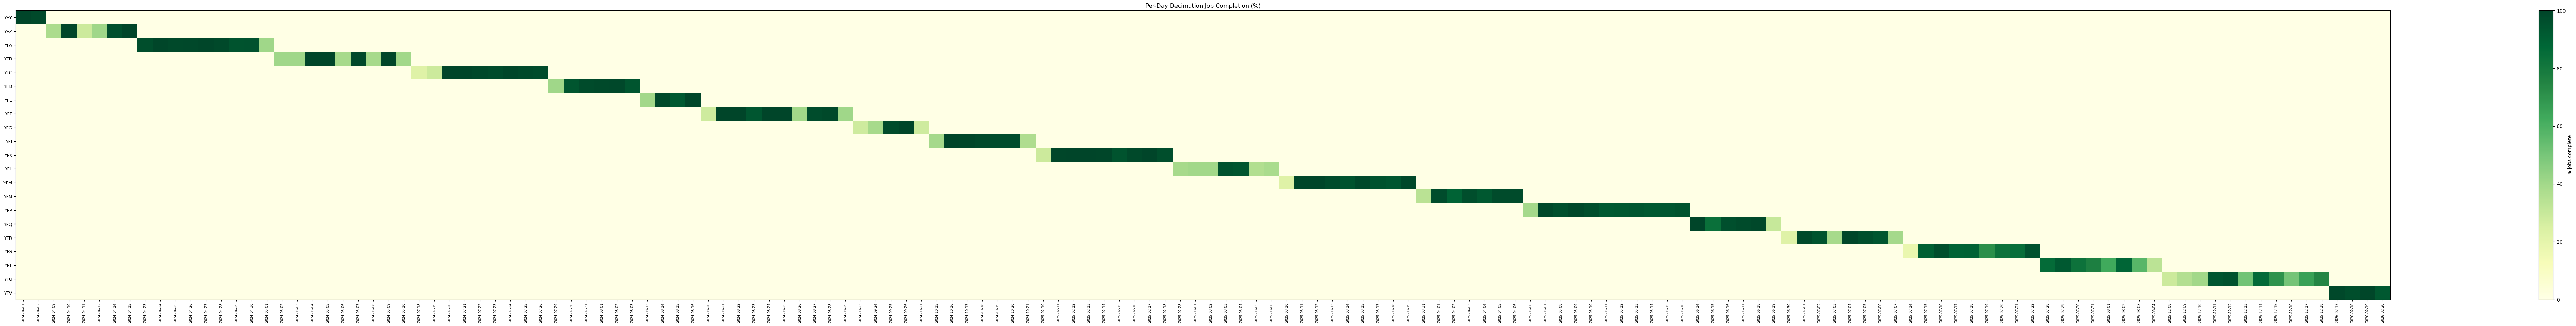

In [6]:
# per-day job completion table + heatmap
perd_audit_rows = []
heatmap_data    = []

for pt in all_patients:
    pd_base = VAD_ROOT / pt / DEC_PD_SUBDIR
    if not pd_base.exists():
        perd_audit_rows.append(dict(patient=pt, n_days=0, jobs_done=0, jobs_total=0, pct=0))
        continue
    days = sorted(d.name for d in pd_base.iterdir() if d.is_dir())
    total_exp  = len(days) * sum(N_SAMPLES)
    total_done = 0
    for day in days:
        day_done = sum(
            1 for p_idx, p in enumerate(PORTIONS)
            for s in range(N_SAMPLES[p_idx])
            if (pd_base / day / f'{pt}_portion{p}_sample{s}_SUCCESS').exists()
        )
        total_done += day_done
        heatmap_data.append(dict(
            patient=pt, date=day,
            pct=round(100 * day_done / sum(N_SAMPLES), 1)
        ))
    perd_audit_rows.append(dict(
        patient=pt, n_days=len(days),
        jobs_done=total_done, jobs_total=total_exp,
        pct=round(100 * total_done / total_exp, 1) if total_exp else 0
    ))

perd_audit = pd.DataFrame(perd_audit_rows)
print('=== Per-Day Decimation Status ===')
display(perd_audit[perd_audit['n_days'] > 0])

# heatmap: rows=patients, columns=dates, colour=completion %
hm_df = pd.DataFrame(heatmap_data)
if len(hm_df) > 0:
    pivot = hm_df.pivot(index='patient', columns='date', values='pct').fillna(0)
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 0.55),
                                    max(4, len(pivot) * 0.45)))
    im = ax.imshow(pivot.values, aspect='auto', vmin=0, vmax=100, cmap='YlGn')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    plt.colorbar(im, ax=ax, label='% jobs complete')
    ax.set_title('Per-Day Decimation Job Completion (%)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'data_availability_heatmap.svg', format='svg')
    plt.show()

## 1. Load Decimation Results

Loads all available PKL files (summary rows only) into DataFrames and caches the result.
First run for per-day data may take ~3–5 minutes; subsequent runs use the cache.

In [7]:
alld_cache = CACHE_DIR / 'alld_dec_df.pkl'


def expected_alld_pkl_paths():
    rows = []
    for pt in all_patients:
        if pt not in sig_neurons:
            continue
        dec_dir = VAD_ROOT / pt / DEC_SUBDIR
        if not dec_dir.exists():
            continue
        for p_idx, portion in enumerate(PORTIONS):
            for sample in range(N_SAMPLES[p_idx]):
                pkl = dec_dir / f'{pt}_portion{portion}_sample{sample}_encoding_results_cv.pkl'
                if pkl.exists():
                    rows.append((pt, float(portion), int(sample), pkl))
    return pd.DataFrame(rows, columns=['patient', 'portion', 'sample', 'path'])


def alld_cache_is_fresh(df, expected):
    if FORCE_RELOAD or df is None:
        return False
    if len(expected) == 0:
        return True
    if len(df) == 0:
        return False
    required = {'patient', 'portion', 'sample', 'neuron_idx', 'pseudo_r2_mean', 'p_val_ll_xshuf'}
    if not required.issubset(df.columns):
        return False
    cached_keys = set(map(tuple, df[['patient', 'portion', 'sample']].drop_duplicates().to_numpy()))
    expected_keys = set(map(tuple, expected[['patient', 'portion', 'sample']].to_numpy()))
    if not expected_keys.issubset(cached_keys):
        missing = len(expected_keys - cached_keys)
        print(f'All-days cache is stale: missing {missing} existing PKL job(s).')
        return False
    if alld_cache.exists():
        cache_mtime = alld_cache.stat().st_mtime
        newest_pkl = max(path.stat().st_mtime for path in expected['path'])
        if newest_pkl > cache_mtime:
            print('All-days cache is stale: result PKLs are newer than the cache.')
            return False
    return True


alld_expected = expected_alld_pkl_paths()
print(f'All-days PKLs available on disk: {len(alld_expected):,}')

if alld_cache.exists() and not FORCE_RELOAD:
    with open(alld_cache, 'rb') as f:
        cached_alld_df = pickle.load(f)
    if alld_cache_is_fresh(cached_alld_df, alld_expected):
        alld_df = cached_alld_df
        print(f'Loaded alld_df from cache: {len(alld_df):,} rows, '
              f'{alld_df["patient"].nunique()} patients')
    else:
        alld_df = None
else:
    alld_df = None

if alld_df is None:
    records = []
    n_loaded = 0
    for row in alld_expected.itertuples(index=False):
        with open(row.path, 'rb') as f:
            df = pickle.load(f)
        summ = df[df['is_summary'] == True][
            ['portion', 'sample', 'neuron_idx', 'pseudo_r2_mean', 'p_val_ll_xshuf']
        ].copy()
        summ['patient'] = row.patient
        records.append(summ)
        n_loaded += 1

    if records:
        alld_df = pd.concat(records, ignore_index=True)
    else:
        alld_df = pd.DataFrame(columns=['patient', 'portion', 'sample', 'neuron_idx',
                                         'pseudo_r2_mean', 'p_val_ll_xshuf'])
    with open(alld_cache, 'wb') as f:
        pickle.dump(alld_df, f)
    print(f'Loaded {n_loaded} PKLs -> {len(alld_df):,} rows; cache saved.')

if len(alld_df) > 0:
    print(f'Portions present: {sorted(alld_df["portion"].unique())}')
    print(f'Patients: {sorted(alld_df["patient"].unique())}')


All-days PKLs available on disk: 3,071
Loaded alld_df from cache: 155,432 rows, 21 patients
Portions present: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
Patients: ['YEY', 'YEZ', 'YFA', 'YFB', 'YFC', 'YFD', 'YFE', 'YFF', 'YFG', 'YFI', 'YFK', 'YFL', 'YFM', 'YFN', 'YFP', 'YFQ', 'YFR', 'YFS', 'YFT', 'YFU', 'YFV']


In [8]:
perd_cache = CACHE_DIR / 'perd_dec_df.pkl'

if perd_cache.exists() and not FORCE_RELOAD:
    with open(perd_cache, 'rb') as f:
        perd_df = pickle.load(f)
    print(f'Loaded perd_df from cache: {len(perd_df):,} rows, '
          f'{perd_df["patient"].nunique()} patients')
else:
    print('Loading per-day PKLs (may take a few minutes)...')
    records = []
    n_loaded = 0
    for pt in all_patients:
        if pt not in sig_neurons:
            continue
        pd_base = VAD_ROOT / pt / DEC_PD_SUBDIR
        if not pd_base.exists():
            continue
        for day_dir in sorted(pd_base.iterdir()):
            if not day_dir.is_dir():
                continue
            date_str = day_dir.name
            n_day_w  = n_words_per_day.get((pt, date_str))
            for p_idx, portion in enumerate(PORTIONS):
                for sample in range(N_SAMPLES[p_idx]):
                    pkl = day_dir / f'{pt}_portion{portion}_sample{sample}_encoding_results_cv.pkl'
                    if not pkl.exists():
                        continue
                    with open(pkl, 'rb') as f:
                        df = pickle.load(f)
                    summ = df[df['is_summary'] == True][
                        ['portion', 'sample', 'neuron_idx', 'pseudo_r2_mean', 'p_val_ll_xshuf']
                    ].copy()
                    summ['patient']     = pt
                    summ['date']        = date_str
                    summ['n_day_words'] = n_day_w
                    records.append(summ)
                    n_loaded += 1
                    if n_loaded % 1000 == 0:
                        print(f'  {n_loaded} PKLs loaded...')

    if records:
        perd_df = pd.concat(records, ignore_index=True)
    else:
        perd_df = pd.DataFrame(columns=['patient', 'date', 'n_day_words', 'portion', 'sample',
                                         'neuron_idx', 'pseudo_r2_mean', 'p_val_ll_xshuf'])
    with open(perd_cache, 'wb') as f:
        pickle.dump(perd_df, f)
    print(f'Loaded {n_loaded} PKLs -> {len(perd_df):,} rows; cache saved.')

if len(perd_df) > 0:
    print(f'Portions present: {sorted(perd_df["portion"].unique())}')
    print(f'Patients: {sorted(perd_df["patient"].unique())}')

Loaded perd_df from cache: 1,099,752 rows, 21 patients
Portions present: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
Patients: ['YEY', 'YEZ', 'YFA', 'YFB', 'YFC', 'YFD', 'YFE', 'YFF', 'YFG', 'YFI', 'YFK', 'YFL', 'YFM', 'YFN', 'YFP', 'YFQ', 'YFR', 'YFS', 'YFT', 'YFU', 'YFV']


## 2. Helper Functions

In [9]:
def hill_b(x, b, A, K, h):
    x = np.asarray(x, float)
    return b + A * (x**h / (K**h + x**h))


def fit_hill_weighted_mse(x, y, w, maxiter=30000):
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[m], y[m], w[m]
    w = w / np.mean(w)
    lo = x <= np.percentile(x, 5)
    hi = x >= np.percentile(x, 95)
    b0 = np.median(y[lo]) if lo.any() else np.median(y)
    A0 = max(1e-6, (np.median(y[hi]) if hi.any() else np.median(y)) - b0)
    K0, h0 = np.median(x), 1.0

    def obj(p):
        return float(np.sum(w * (y - hill_b(x, *p))**2))

    res = minimize(obj, [b0, A0, K0, h0],
                   bounds=[(None, None), (0, None), (1e-6, None), (1e-3, 20)],
                   method='L-BFGS-B', options={'maxiter': maxiter})
    return res.x, float(res.fun), (x, y, w)


def fit_linear_weighted_mse(x, y, w):
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[m], y[m], w[m]
    w = w / np.mean(w)
    X = np.column_stack([np.ones_like(x), x])
    sw = np.sqrt(w)
    beta = np.linalg.lstsq(X * sw[:, None], y * sw, rcond=None)[0]
    r = y - (beta[0] + beta[1] * x)
    return beta, float(np.sum(w * r**2))


def permutation_pvalue_hill_vs_null_mse(x, y, w, n_perm=100, seed=0):
    rng = np.random.default_rng(seed)
    params, loss_real, (xu, yu, wu) = fit_hill_weighted_mse(x, y, w)
    losses = []
    for _ in range(n_perm):
        _, lp, _ = fit_hill_weighted_mse(rng.permutation(xu), yu, wu, maxiter=8000)
        losses.append(lp)
    p = (np.sum(np.array(losses) <= loss_real) + 1) / (n_perm + 1)
    return float(p), loss_real, losses


def format_p(p):
    if p < 1e-3:
        return 'p < 1e-3'
    if p < 1e-2:
        return f'p = {p:.2e}'
    return f'p = {p:.3f}'


def format_loss(v):
    if abs(v) >= 1e4:
        return f'{v:.2e}'
    if abs(v) >= 1e2:
        return f'{v:.1f}'
    return f'{v:.3f}'


print('Hill utilities loaded; linear comparator uses true WLS weights.')

Hill utilities loaded; linear comparator uses true WLS weights.


In [10]:
from matplotlib.colors import LinearSegmentedColormap

# Paper-themed sequential: white → mint → bright green → cerulean → purple
PAPER_CMAP = LinearSegmentedColormap.from_list(
    'paper_hot',
    ['#FFFFFF', '#daedde', '#41b373', '#3e71b8', '#8a5ba6']
)


def clip_pseudo_r2_for_display(df, y_col='pseudo_r2_mean'):
    if PSEUDO_R2_DISPLAY_RANGE is None or len(df) == 0:
        return df.copy()
    lo, hi = PSEUDO_R2_DISPLAY_RANGE
    return df[df[y_col].between(lo, hi, inclusive='both')].copy()


def plot_boxplot_hill(df, ax, title='', y_col='pseudo_r2_mean', n_perm=100):
    """Boxplots + Hill curve for pseudo_r2 vs portion."""
    if df is None or len(df) == 0 or df['portion'].nunique() < 2:
        msg = ('No data available'
               if (df is None or len(df) == 0)
               else f'Only {df["portion"].nunique()} portion(s) available')
        ax.text(0.5, 0.5, msg, ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray', style='italic')
        ax.set_title(title)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    valid = df[np.isfinite(df[y_col])].copy()
    n_before = len(valid)
    valid = clip_pseudo_r2_for_display(valid, y_col)
    n_clipped = n_before - len(valid)
    if len(valid) == 0 or valid['portion'].nunique() < 2:
        ax.text(0.5, 0.5, 'No in-range pseudo R2 data', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray', style='italic')
        ax.set_title(title)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    props = sorted(valid['portion'].unique())
    x = valid['portion'].to_numpy(float)
    y = valid[y_col].to_numpy(float)

    counts = pd.Series(x).value_counts().to_dict()
    w = np.array([1.0 / counts[v] for v in x])
    w = w / np.mean(w)

    fit_ok = False
    hill_loss = np.nan
    try:
        res, hill_loss, _ = fit_hill_weighted_mse(x, y, w)
        b_hat, A_hat, K_hat, h_hat = res
        fit_ok = True
    except Exception:
        pass

    span   = max(props) - min(props) if len(props) > 1 else 1.0
    widths = min(0.03, span / len(props) * 0.8)
    groups = [valid.loc[valid['portion'] == p, y_col].values for p in props]
    ax.boxplot(
        groups, positions=props, widths=widths,
        showfliers=False, patch_artist=True,
        boxprops=dict(facecolor=BOX_FC, edgecolor=EDGE_C, linewidth=1.2, alpha=0.75),
        whiskerprops=dict(color=EDGE_C, linewidth=1.2),
        capprops=dict(color=EDGE_C, linewidth=1.2),
        medianprops=dict(color=CURVE_C, linewidth=2.2),
    )

    if fit_ok:
        x_fit = np.linspace(min(props), max(props), 400)
        ax.plot(x_fit, hill_b(x_fit, b_hat, A_hat, K_hat, h_hat),
                color=CURVE_C, lw=1.8, zorder=10, alpha=0.9)

    ax.axhline(0, color='gray', linestyle='--', lw=1.0, alpha=0.3)

    if fit_ok and len(props) >= 3:
        try:
            p_perm, _, _ = permutation_pvalue_hill_vs_null_mse(x, y, w, n_perm=n_perm, seed=0)
            _, lin_loss  = fit_linear_weighted_mse(x, y, w)
            l1 = f'Hill vs null: {format_p(p_perm)}'
            l2 = f'dLoss (Hill-lin): {format_loss(hill_loss - lin_loss)}'
            stats_txt = l1 + '\n' + l2
            if n_clipped:
                stats_txt += f'\nclipped {n_clipped:,} outlier rows'
        except Exception:
            stats_txt = 'Stats unavailable'
    else:
        stats_txt = f'{len(props)} portion(s) available'

    ax.text(0.02, 0.98, stats_txt, transform=ax.transAxes,
            ha='left', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor='none', alpha=0.8))

    pad = 0.03 * span if len(props) > 1 else 0.05
    ax.set_xlim(min(props) - pad, max(props) + pad)
    ax.set_xticks(props)
    ax.set_xticklabels([f'{p:g}' for p in props], rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Proportion of data used')
    ax.set_ylabel('pseudo $r^2$')
    if PSEUDO_R2_DISPLAY_RANGE is not None:
        ax.set_ylim(*PSEUDO_R2_DISPLAY_RANGE)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_2dhist_hill(df, ax, title='', y_col='pseudo_r2_mean', n_perm=100):
    """2D relative-density histogram + Hill curve for pseudo_r2 vs word count."""
    if df is None or len(df) == 0 or 'word_count' not in df.columns:
        msg = 'No data' if (df is None or len(df) == 0) else 'word_count missing'
        ax.text(0.5, 0.5, msg, ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray', style='italic')
        ax.set_title(title)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    sub = df[['word_count', y_col]].dropna()
    n_before = len(sub)
    sub = clip_pseudo_r2_for_display(sub, y_col)
    n_clipped = n_before - len(sub)
    if len(sub) < 20 or sub['word_count'].nunique() < 3:
        ax.text(0.5, 0.5, f'Insufficient data ({len(sub)} pts)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='gray', style='italic')
        ax.set_title(title)
        return

    xv = sub['word_count'].to_numpy(float)
    yv = sub[y_col].to_numpy(float)
    x_min, x_max = max(1, xv.min()), xv.max()
    y_min, y_max = yv.min(), yv.max()

    nx = 120
    x_edges = np.unique(np.round(np.geomspace(x_min, x_max, nx)).astype(int))
    x_edges = x_edges[x_edges > 0]
    x_edges = np.unique(x_edges).astype(float)
    if len(x_edges) < 10:
        x_edges = np.linspace(x_min, x_max, nx)

    ny = 220
    ye = np.linspace(y_min, y_max, ny)

    H, ye, xe = np.histogram2d(yv, xv, bins=[ye, x_edges])
    col_sums  = H.sum(axis=0, keepdims=True)
    H_rel     = np.divide(H, col_sums, out=np.zeros_like(H, float), where=col_sums > 0)

    pos = H_rel[H_rel > 0]
    if pos.size:
        H_rel[H_rel < np.percentile(pos, 5)] = 0.0
    gamma = 6
    H_rel = np.power(H_rel, gamma, where=H_rel > 0, out=H_rel)

    pos2 = H_rel[H_rel > 0]
    vmax = np.percentile(pos2, 99) if pos2.size else 1.0
    eps  = 1e-12
    cmap = PAPER_CMAP.copy()
    cmap.set_bad(alpha=0.0)
    H_plot = np.ma.masked_where(H_rel <= 0, H_rel)
    mesh = ax.pcolormesh(xe, ye, H_plot, shading='auto', cmap=cmap,
                         norm=LogNorm(vmin=eps, vmax=vmax))
    plt.colorbar(mesh, ax=ax, label='Relative density')

    x_bin = np.digitize(xv, x_edges) - 1
    valid = (x_bin >= 0) & (x_bin < len(x_edges) - 1)
    xf, yf, xb = xv[valid], yv[valid], x_bin[valid]
    bc = np.bincount(xb, minlength=len(x_edges) - 1)
    w  = 1.0 / np.maximum(bc[xb], 1)
    w  = w / np.mean(w)

    stats_txt = ''
    try:
        res, hill_loss, _ = fit_hill_weighted_mse(xf, yf, w)
        b_hat, A_hat, K_hat, h_hat = res
        x_line = np.geomspace(x_min, x_max, 600)
        ax.plot(x_line, hill_b(x_line, b_hat, A_hat, K_hat, h_hat),
                color=CURVE_C, lw=2.0, zorder=5, alpha=0.9)
        p_perm, _, _  = permutation_pvalue_hill_vs_null_mse(xf, yf, w, n_perm=n_perm, seed=0)
        _, lin_loss   = fit_linear_weighted_mse(xf, yf, w)
        l1 = f'Hill vs null: {format_p(p_perm)}'
        l2 = f'dLoss (Hill-lin): {format_loss(hill_loss - lin_loss)}'
        stats_txt = l1 + '\n' + l2
        if n_clipped:
            stats_txt += f'\nclipped {n_clipped:,} outlier rows'
    except Exception as e:
        stats_txt = f'Fit error: {str(e)[:50]}'

    ax.axhline(0, linestyle='--', lw=1.0, alpha=0.25, color='gray')
    if stats_txt:
        ax.text(0.02, 0.98, stats_txt, transform=ax.transAxes,
                ha='left', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='none', alpha=0.8))
    ax.set_xscale('log')
    ax.set_xlabel('Number of words in sample')
    ax.set_ylabel('pseudo $r^2$')
    if PSEUDO_R2_DISPLAY_RANGE is not None:
        ax.set_ylim(*PSEUDO_R2_DISPLAY_RANGE)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_scatter_sig_frac(df, ax, title=''):
    """Scatter: fraction significant neurons vs portion of data."""
    if df is None or len(df) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray', style='italic')
        ax.set_title(title)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return
    if df['portion'].nunique() < 2:
        ax.text(0.5, 0.5, f'Only {df["portion"].nunique()} portion(s)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='gray', style='italic')
        ax.set_title(title)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    rng   = np.random.default_rng(42)
    x_jit = df['portion'].to_numpy(float) + rng.uniform(-0.015, 0.015, len(df))
    # Very low alpha so clusters read as density rather than individual points
    ax.scatter(x_jit, df['sig_frac'].to_numpy(float),
               c=SCATTER_C, alpha=0.20, s=6, linewidths=0)

    means = df.groupby('portion')['sig_frac'].mean().sort_index()
    ax.plot(means.index, means.values, 'o-', color=CURVE_C,
            lw=2.0, ms=6, zorder=5, label='Mean',
            markeredgecolor='white', markeredgewidth=0.8)

    portions = sorted(df['portion'].unique())
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(portions)
    ax.set_xticklabels([f'{p:g}' for p in portions], rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Portion of data used')
    ax.set_ylabel('Fraction of neurons significant\n(p < 0.05, pseudo r2 > 0)')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


print('Plot functions loaded.')


Plot functions loaded.


## 3. Build Panel DataFrames

In [11]:
def filter_sig_neurons(dec_df, sig_ns):
    """Keep only rows for neurons significant in the standard (full-data) encoding."""
    if len(dec_df) == 0:
        return dec_df.copy()
    rows = []
    for pt, grp in dec_df.groupby('patient'):
        if pt not in sig_ns or len(sig_ns[pt]) == 0:
            continue
        rows.append(grp[grp['neuron_idx'].isin(sig_ns[pt])])
    if not rows:
        return pd.DataFrame(columns=dec_df.columns)
    out = pd.concat(rows, ignore_index=True)
    return out[np.isfinite(out['pseudo_r2_mean'])].copy()


# panels A & C: portion-level boxplot data
panA_df = filter_sig_neurons(alld_df, sig_neurons)
panC_df = filter_sig_neurons(perd_df, sig_neurons)

print(f'Panel A: {len(panA_df):,} rows | '
      f'{panA_df["patient"].nunique() if len(panA_df) else 0} patients | '
      f'{panA_df["portion"].nunique() if len(panA_df) else 0} portions')
print(f'Panel C: {len(panC_df):,} rows | '
      f'{panC_df["patient"].nunique() if len(panC_df) else 0} patients | '
      f'{panC_df["portion"].nunique() if len(panC_df) else 0} portions')


# panels B & D: add word_count column
def add_word_count_alld(df):
    if len(df) == 0:
        return df
    df = df.copy()
    df['word_count'] = df.apply(
        lambda r: round(r['portion'] * n_words_all[r['patient']])
        if r['patient'] in n_words_all else np.nan,
        axis=1
    )
    return df


def add_word_count_perd(df):
    if len(df) == 0:
        return df
    df = df.copy()
    df['word_count'] = df.apply(
        lambda r: round(r['portion'] * r['n_day_words'])
        if pd.notna(r.get('n_day_words')) else np.nan,
        axis=1
    )
    return df


panB_df = add_word_count_alld(panA_df)
panD_df = add_word_count_perd(panC_df)

if len(panB_df) > 0 and 'word_count' in panB_df.columns:
    wc = panB_df['word_count'].dropna()
    print(f'Panel B word_count: {wc.min():.0f} – {wc.max():.0f}')
if len(panD_df) > 0 and 'word_count' in panD_df.columns:
    wc = panD_df['word_count'].dropna()
    print(f'Panel D word_count: {wc.min():.0f} – {wc.max():.0f}')

Panel A: 155,432 rows | 21 patients | 12 portions
Panel C: 1,099,752 rows | 21 patients | 12 portions


Panel B word_count: 404 – 521360
Panel D word_count: 128 – 75770


In [12]:
# panels E & F: fraction significant neurons vs portion
# Main panels use the conservative definition from the decimation PKL:
# permutation p-value plus positive pseudo-R2. Supplementary p-only panels
# check whether that pseudo-R2 > 0 guard changes the apparent power curve.

def make_sig_frac_df(df, group_cols, require_positive_r2=True):
    rows = []
    if len(df) == 0:
        return pd.DataFrame(rows)
    for keys, grp in df.groupby(group_cols):
        n_total = len(grp)
        if n_total == 0:
            continue
        sig_mask = grp['p_val_ll_xshuf'] < SIG_PVAL
        if require_positive_r2:
            sig_mask = sig_mask & (grp['pseudo_r2_mean'] > SIG_R2_MIN)
        n_sig = int(sig_mask.sum())
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(n_sig=n_sig, n_total=n_total, sig_frac=n_sig / n_total)
        rows.append(row)
    out = pd.DataFrame(rows)
    if len(out) > 0:
        out['portion'] = out['portion'].astype(float)
        out['sample'] = out['sample'].astype(int)
    return out


panE_df = make_sig_frac_df(
    alld_df, ['patient', 'portion', 'sample'], require_positive_r2=True
)
print(f'Panel E: {len(panE_df):,} points | '
      f'{panE_df["portion"].nunique() if len(panE_df) else 0} portions')

panF_df = make_sig_frac_df(
    perd_df, ['patient', 'date', 'portion', 'sample'], require_positive_r2=True
)
print(f'Panel F: {len(panF_df):,} points | '
      f'{panF_df["portion"].nunique() if len(panF_df) else 0} portions')

# Supplementary E/F analogs: permutation p-value only.
panE_ponly_df = make_sig_frac_df(
    alld_df, ['patient', 'portion', 'sample'], require_positive_r2=False
)
print(f'Supp p-only E: {len(panE_ponly_df):,} points | '
      f'{panE_ponly_df["portion"].nunique() if len(panE_ponly_df) else 0} portions')

panF_ponly_df = make_sig_frac_df(
    perd_df, ['patient', 'date', 'portion', 'sample'], require_positive_r2=False
)
print(f'Supp p-only F: {len(panF_ponly_df):,} points | '
      f'{panF_ponly_df["portion"].nunique() if len(panF_ponly_df) else 0} portions')


Panel E: 3,071 points | 12 portions
Panel F: 20,705 points | 12 portions
Supp p-only E: 3,071 points | 12 portions
Supp p-only F: 20,705 points | 12 portions


## Supp A: All-Days — pseudo-R² vs Proportion

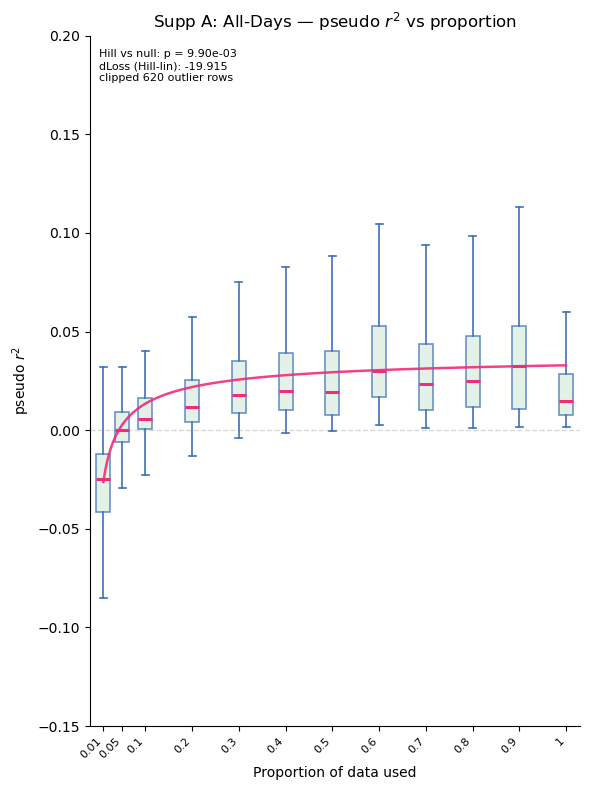

In [13]:
fig, ax = plt.subplots(figsize=(6, 8))
plot_boxplot_hill(panA_df, ax, title='Supp A: All-Days — pseudo $r^2$ vs proportion')
plt.tight_layout()
plt.savefig(FIG_DIR / 'suppA_alld_boxplot_portion.svg', format='svg')
plt.show()


## Supp B: All-Days — pseudo-R² vs Word Count

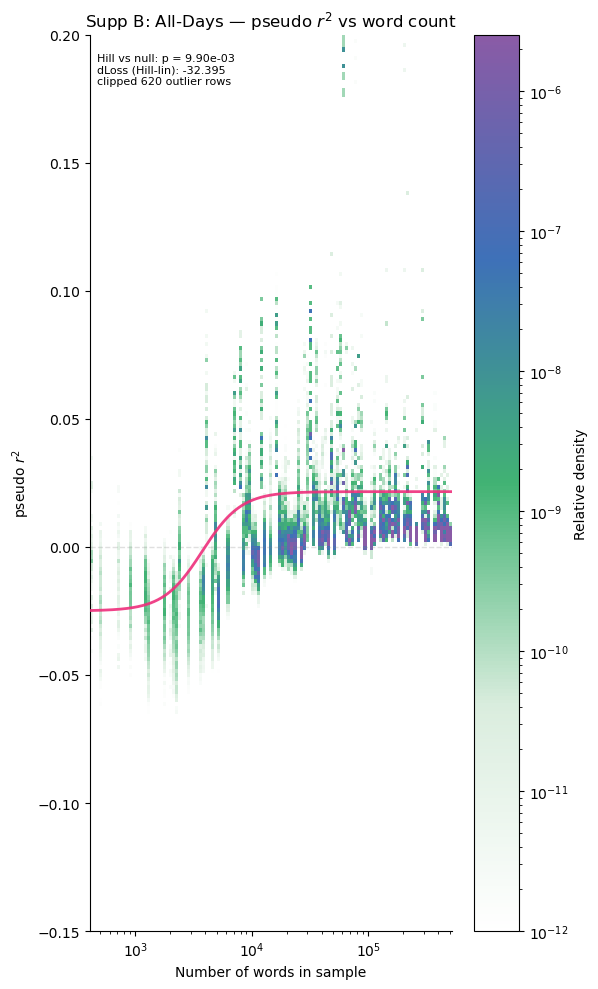

In [14]:
fig, ax = plt.subplots(figsize=(6, 10))
plot_2dhist_hill(panB_df, ax, title='Supp B: All-Days — pseudo $r^2$ vs word count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'suppB_alld_2dhist_wordcount.svg', format='svg')
plt.show()


## Panel A: Per-Day — pseudo-R² vs Proportion

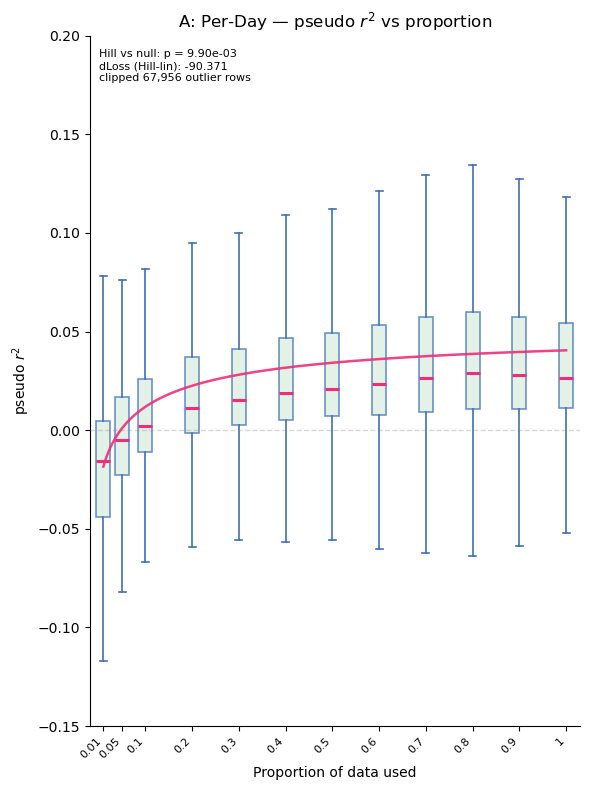

In [15]:
fig, ax = plt.subplots(figsize=(6, 8))
plot_boxplot_hill(panC_df, ax, title='A: Per-Day — pseudo $r^2$ vs proportion')
plt.tight_layout()
plt.savefig(FIG_DIR / 'panelA_perd_boxplot_portion.svg', format='svg')
plt.savefig(FIG_DIR / 'panelA_perd_boxplot_portion.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [16]:
# ── Panel A: x-intercept of Hill fit (portion where pseudo-R² crosses 0) ────
# Hill: y = b + A * x^h / (K^h + x^h)  →  setting y=0 and solving for x:
#   x_int = K * (-b / (A + b))^(1/h)
# Valid only when b < 0 and A + b > 0.
#
# SE via delta method (error propagation):
#   Var(x_int) ≈ ∇x_int^T · Cov(θ) · ∇x_int,  Cov(θ) ≈ σ² (JᵀWJ)⁻¹

def hill_xintercept(b, A, K, h):
    denom = A + b
    if denom == 0:
        return np.nan
    ratio = -b / denom
    if not (np.isfinite(ratio) and ratio > 0):
        return np.nan
    return float(K * ratio ** (1.0 / h))


def delta_method_xintercept_se(x, y, w, params, ci=95):
    """SE and CI of the Hill x-intercept via error propagation (delta method)."""
    b, A, K, h = params
    denom = A + b
    ratio = -b / denom
    if not (np.isfinite(ratio) and ratio > 0):
        return np.nan, np.nan, np.nan

    xi = float(K * ratio ** (1.0 / h))

    # Gradient of x_int w.r.t. (b, A, K, h)
    dxi_dr = K * (1.0 / h) * ratio ** (1.0 / h - 1)
    grad = np.array([
        dxi_dr * (-A / denom**2),       # ∂x_int/∂b
        dxi_dr * ( b / denom**2),       # ∂x_int/∂A
        xi / K,                          # ∂x_int/∂K
        -xi * np.log(ratio) / h**2,     # ∂x_int/∂h
    ])

    # Model Jacobian: each row is [∂f/∂b, ∂f/∂A, ∂f/∂K, ∂f/∂h] at x_i
    xp = np.maximum(x, 1e-12)
    xh = xp ** h
    Kh = K ** h
    D  = (Kh + xh) ** 2
    Jm = np.column_stack([
        np.ones_like(x),
        xh / (Kh + xh),
        A * xh * (-h * K**(h-1)) / D,
        A * xh * Kh * np.log(xp / K) / D,
    ])

    JtWJ  = (Jm * w[:, None]).T @ Jm
    y_hat = b + A * xh / (Kh + xh)
    sigma2 = np.sum(w * (y - y_hat)**2) / max(len(x) - 4, 1)

    try:
        cov_theta = sigma2 * np.linalg.inv(JtWJ)
        var_xi = float(grad @ cov_theta @ grad)
        se_xi  = float(np.sqrt(max(0.0, var_xi)))
    except np.linalg.LinAlgError:
        return xi, np.nan, np.nan

    from scipy.stats import norm
    z = norm.ppf(0.5 + ci / 200)
    return xi, se_xi, z * se_xi   # (x_intercept, SE, half-width of CI)


# Prepare data the same way plot_boxplot_hill does (panC_df = per-day data)
_df_A = panC_df[np.isfinite(panC_df['pseudo_r2_mean'])].copy()
_df_A = clip_pseudo_r2_for_display(_df_A)
_x_A  = _df_A['portion'].to_numpy(float)
_y_A  = _df_A['pseudo_r2_mean'].to_numpy(float)
_cnts = pd.Series(_x_A).value_counts().to_dict()
_w_A  = np.array([1.0 / _cnts[v] for v in _x_A])
_w_A  = _w_A / np.mean(_w_A)

_res_A, _, _ = fit_hill_weighted_mse(_x_A, _y_A, _w_A)
_b_A, _A_A, _K_A, _h_A = _res_A
_xi_A, _se_A, _hw_A = delta_method_xintercept_se(_x_A, _y_A, _w_A, _res_A, ci=95)

print('Panel A — Hill fit parameters:')
print(f'  b={_b_A:.4f}  A={_A_A:.4f}  K={_K_A:.4f}  h={_h_A:.4f}')
print(f'  x-intercept (portion) : {_xi_A:.4f}')
print(f'  SE                    : {_se_A:.4f}')
print(f'  95% CI (portion)      : [{_xi_A - _hw_A:.4f}, {_xi_A + _hw_A:.4f}]')


Panel A — Hill fit parameters:
  b=-0.0318  A=0.0838  K=0.0896  h=0.7600
  x-intercept (portion) : 0.0468
  SE                    : 0.0004
  95% CI (portion)      : [0.0460, 0.0476]


## Panel B: Per-Day — pseudo-R² vs Word Count

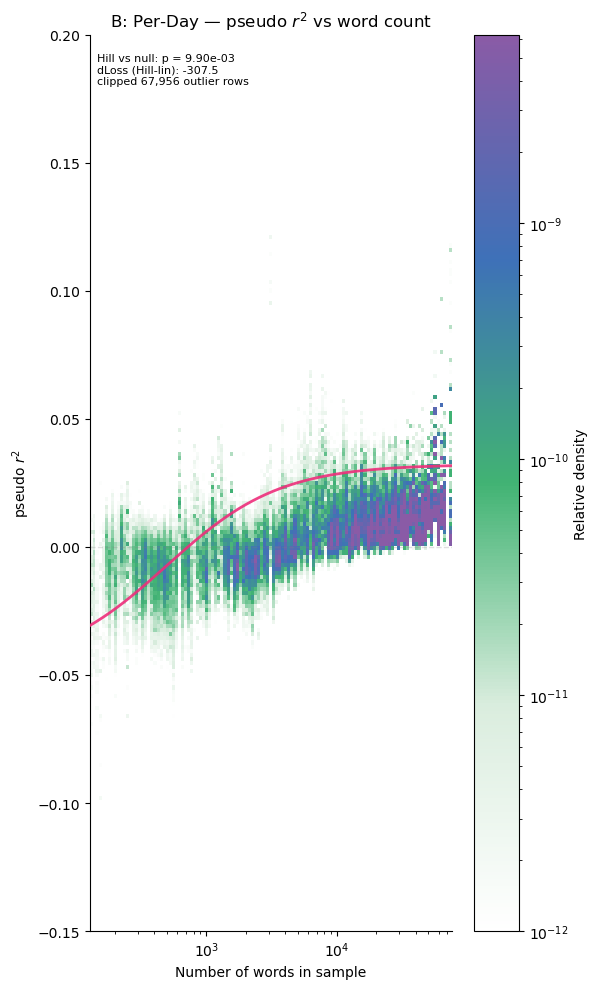

In [17]:
fig, ax = plt.subplots(figsize=(6, 10))
plot_2dhist_hill(panD_df, ax, title='B: Per-Day — pseudo $r^2$ vs word count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'panelB_perd_2dhist_wordcount.svg', format='svg')
plt.savefig(FIG_DIR / 'panelB_perd_2dhist_wordcount.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [18]:
# ── Panel B: x-intercept of Hill fit (n_words where pseudo-R² crosses 0) ────
# Replicates the data prep from plot_2dhist_hill for panD_df.
# Reuses hill_xintercept / delta_method_xintercept_se defined above.

_sub_B = panD_df[['word_count', 'pseudo_r2_mean']].dropna().copy()
_sub_B = clip_pseudo_r2_for_display(_sub_B)
_xv_B  = _sub_B['word_count'].to_numpy(float)
_yv_B  = _sub_B['pseudo_r2_mean'].to_numpy(float)
_x_min_B, _x_max_B = max(1, _xv_B.min()), _xv_B.max()

_x_edges_B = np.unique(np.round(np.geomspace(_x_min_B, _x_max_B, 120)).astype(int))
_x_edges_B = _x_edges_B[_x_edges_B > 0].astype(float)

_x_bin_B = np.digitize(_xv_B, _x_edges_B) - 1
_valid_B  = (_x_bin_B >= 0) & (_x_bin_B < len(_x_edges_B) - 1)
_xf_B, _yf_B, _xb_B = _xv_B[_valid_B], _yv_B[_valid_B], _x_bin_B[_valid_B]
_bc_B = np.bincount(_xb_B, minlength=len(_x_edges_B) - 1)
_w_B  = 1.0 / np.maximum(_bc_B[_xb_B], 1)
_w_B  = _w_B / np.mean(_w_B)

_res_B, _, _ = fit_hill_weighted_mse(_xf_B, _yf_B, _w_B)
_xi_B, _se_B, _hw_B = delta_method_xintercept_se(_xf_B, _yf_B, _w_B, _res_B, ci=95)
_b_B, _A_B, _K_B, _h_B = _res_B

print('Panel B — Hill fit parameters:')
print(f'  b={_b_B:.4f}  A={_A_B:.4f}  K={_K_B:.1f}  h={_h_B:.4f}')
print(f'  x-intercept (n_words) : {_xi_B:.1f}')
print(f'  SE                    : {_se_B:.1f} words')
print(f'  95% CI (n_words)      : [{_xi_B - _hw_B:.1f}, {_xi_B + _hw_B:.1f}]')


Panel B — Hill fit parameters:
  b=-0.0470  A=0.0792  K=497.0  h=1.0010
  x-intercept (n_words) : 724.3
  SE                    : 3.4 words
  95% CI (n_words)      : [717.6, 731.0]


## Supp C: All-Days — Fraction Significant Neurons vs Portion

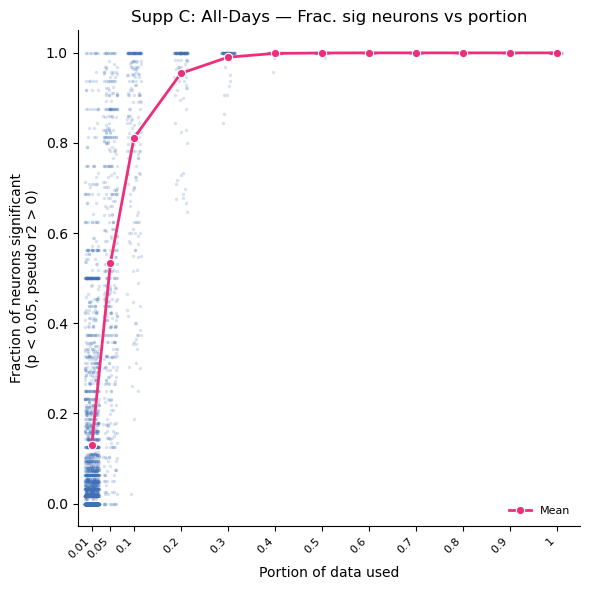

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_scatter_sig_frac(panE_df, ax, title='Supp C: All-Days — Frac. sig neurons vs portion')
plt.tight_layout()
plt.savefig(FIG_DIR / 'suppC_alld_scatter_sigfrac.svg', format='svg')
plt.show()


## Panel C: Per-Day — Fraction Significant Neurons vs Portion

In [20]:
panF_df[panF_df['portion'] == 0.01]['sig_frac'].std() / np.sqrt(len(panF_df[panF_df['portion'] == 0.01]))

np.float64(0.0018224501825094056)

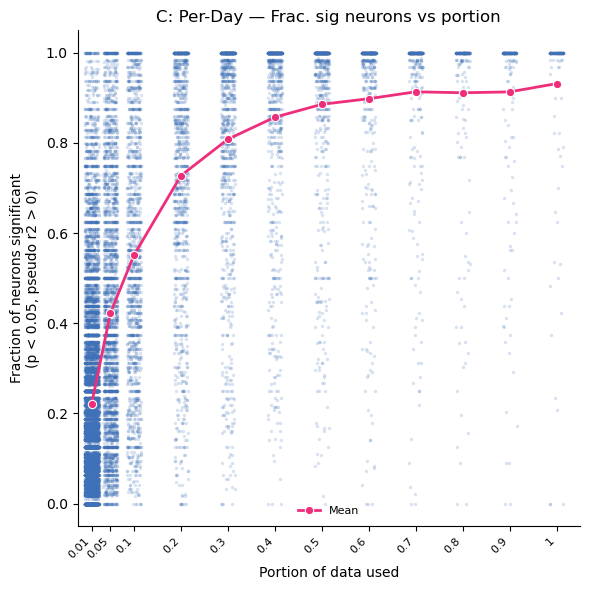

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_scatter_sig_frac(panF_df, ax, title='C: Per-Day — Frac. sig neurons vs portion')
plt.tight_layout()
plt.savefig(FIG_DIR / 'panelC_perd_scatter_sigfrac.svg', format='svg')
plt.savefig(FIG_DIR / 'panelC_perd_scatter_sigfrac.pdf', format='pdf', bbox_inches='tight')
plt.show()


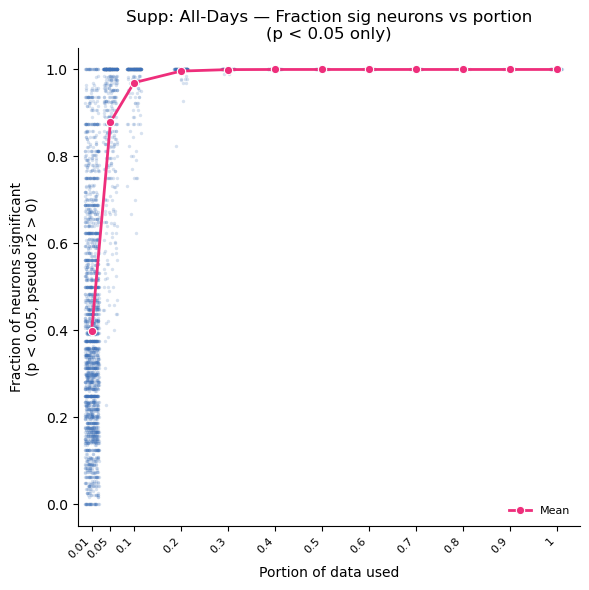

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_scatter_sig_frac(
    panE_ponly_df, ax,
    title='Supp: All-Days — Fraction sig neurons vs portion\n(p < 0.05 only)'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'supp3E_alld_scatter_sigfrac_pvalue_only.svg', format='svg')
plt.show()


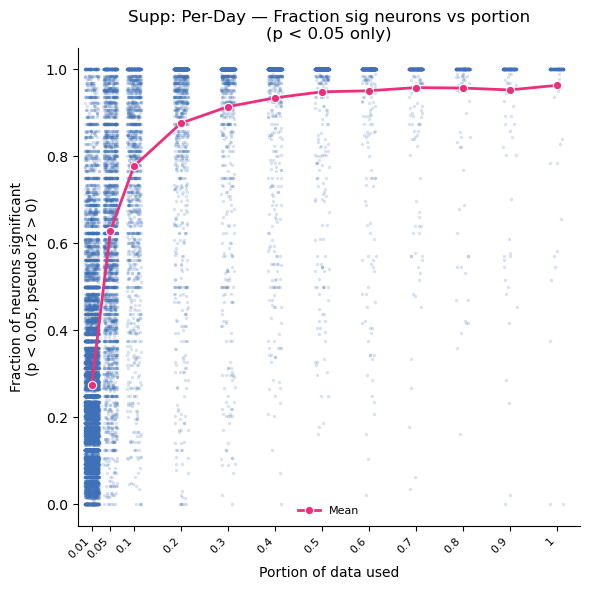

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_scatter_sig_frac(
    panF_ponly_df, ax,
    title='Supp: Per-Day — Fraction sig neurons vs portion\n(p < 0.05 only)'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'supp3F_perd_scatter_sigfrac_pvalue_only.svg', format='svg')
plt.show()


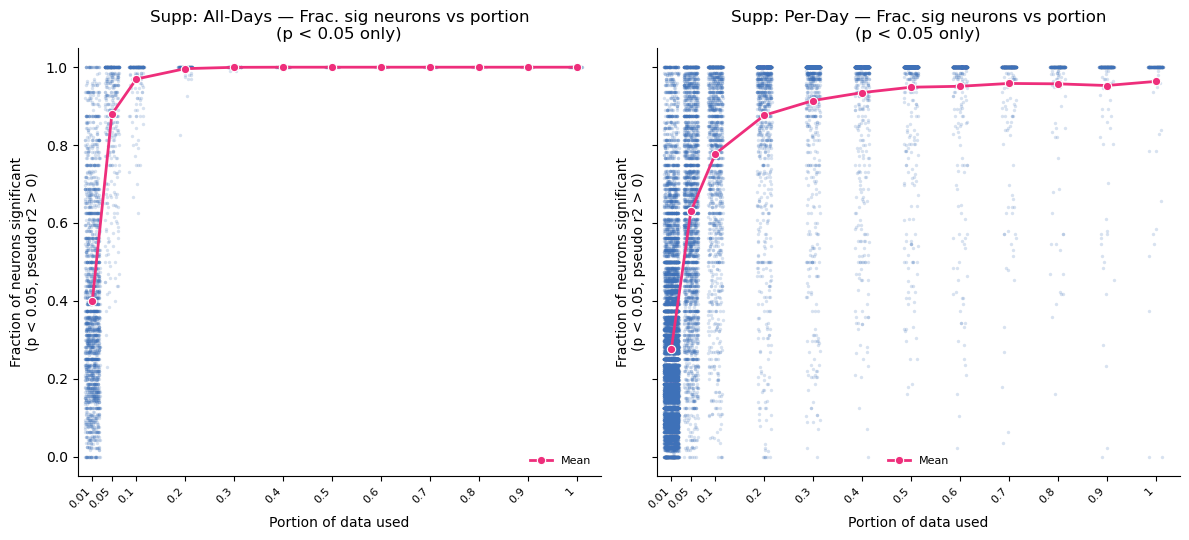

In [24]:
# supplementary panels: p-only fraction significant neurons vs portion
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
plot_scatter_sig_frac(
    panE_ponly_df, axes[0],
    title='Supp: All-Days — Frac. sig neurons vs portion\n(p < 0.05 only)'
)
plot_scatter_sig_frac(
    panF_ponly_df, axes[1],
    title='Supp: Per-Day — Frac. sig neurons vs portion\n(p < 0.05 only)'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'supp3_sigfrac_pvalue_only.svg', format='svg')
plt.savefig(FIG_DIR / 'supp3_sigfrac_pvalue_only.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Supplementary Figure 1: Per-Patient Boxplots (Per-Day, Panel C style)

One plot per patient, Hill curve fit per patient.

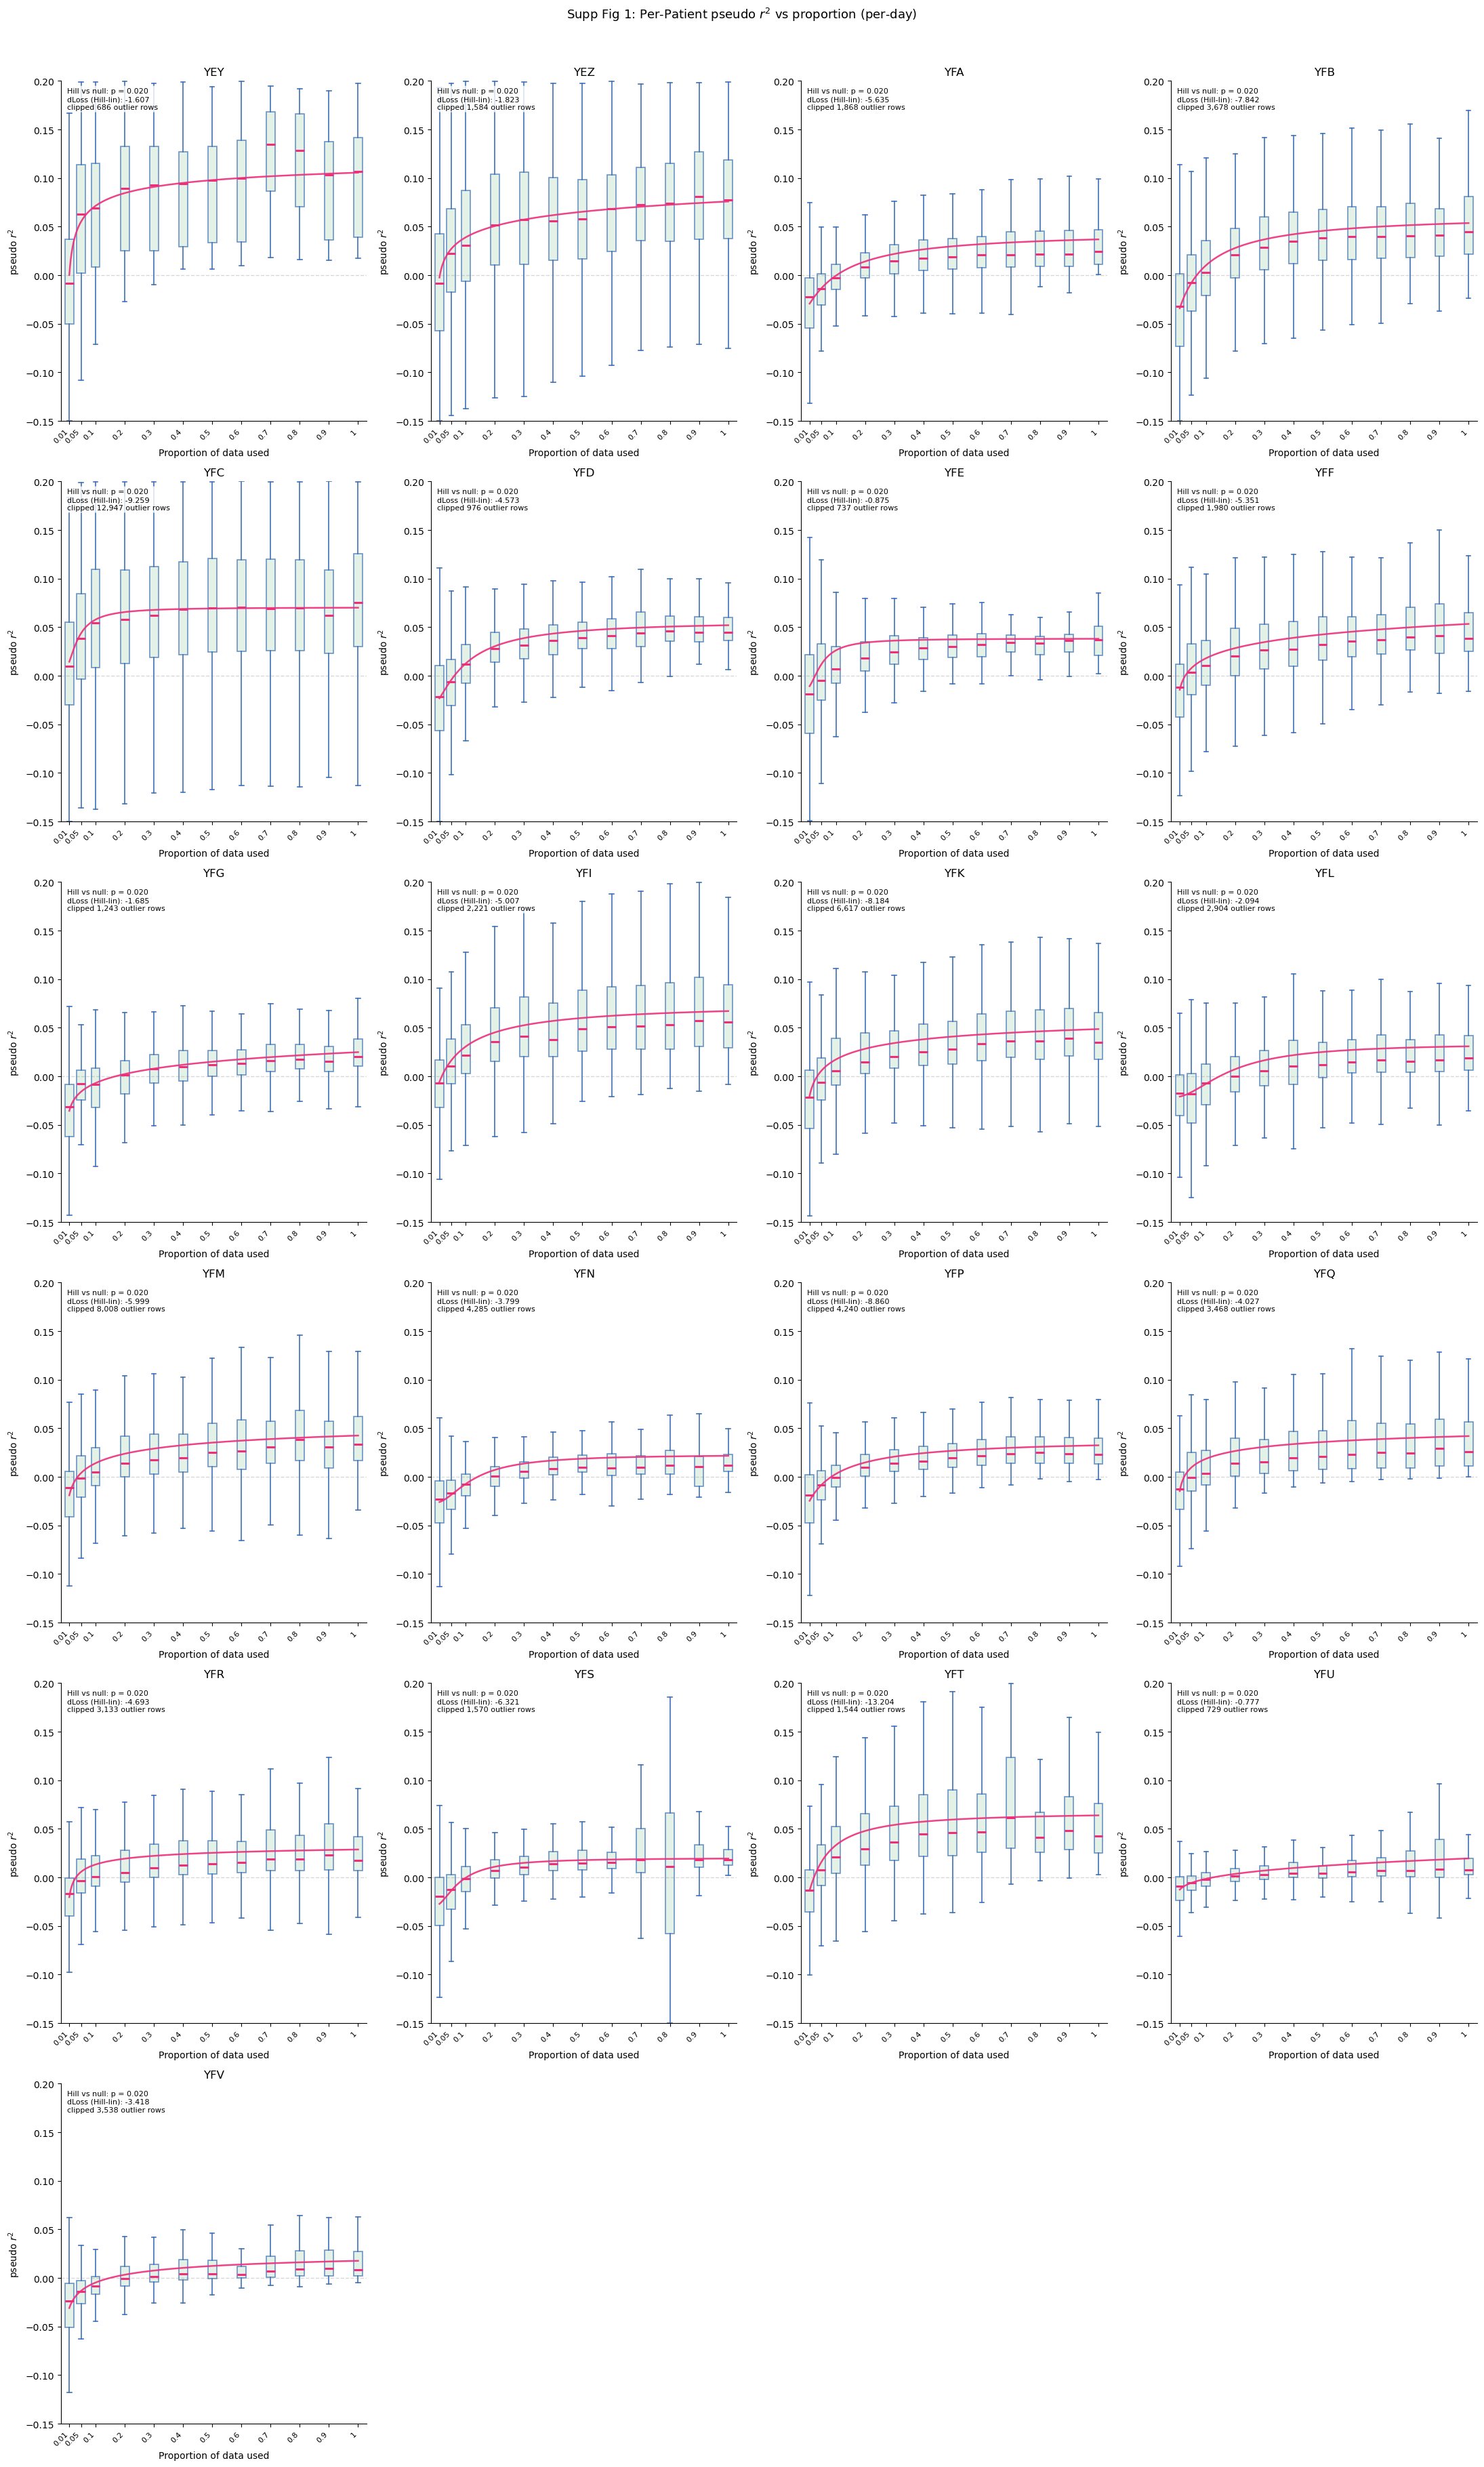

In [25]:
pts_perd = (sorted(panC_df['patient'].unique())
            if len(panC_df) > 0 else [])

if not pts_perd:
    print('No per-day data available for Supp Figure 1.')
else:
    ncols = 4
    nrows = int(np.ceil(len(pts_perd) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 6))
    axes = np.array(axes).flatten()

    for i, pt in enumerate(pts_perd):
        pt_df = panC_df[panC_df['patient'] == pt]
        plot_boxplot_hill(pt_df, axes[i], title=pt, n_perm=50)

    for j in range(len(pts_perd), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Supp Fig 1: Per-Patient pseudo $r^2$ vs proportion (per-day)',
                 y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'supp1_per_patient_boxplot_perd.svg', format='svg')
    plt.show()

## Supplementary Figure 2: Per-Patient 2D Histograms (Per-Day, Panel D style)

One plot per patient, Hill curve fit per patient.

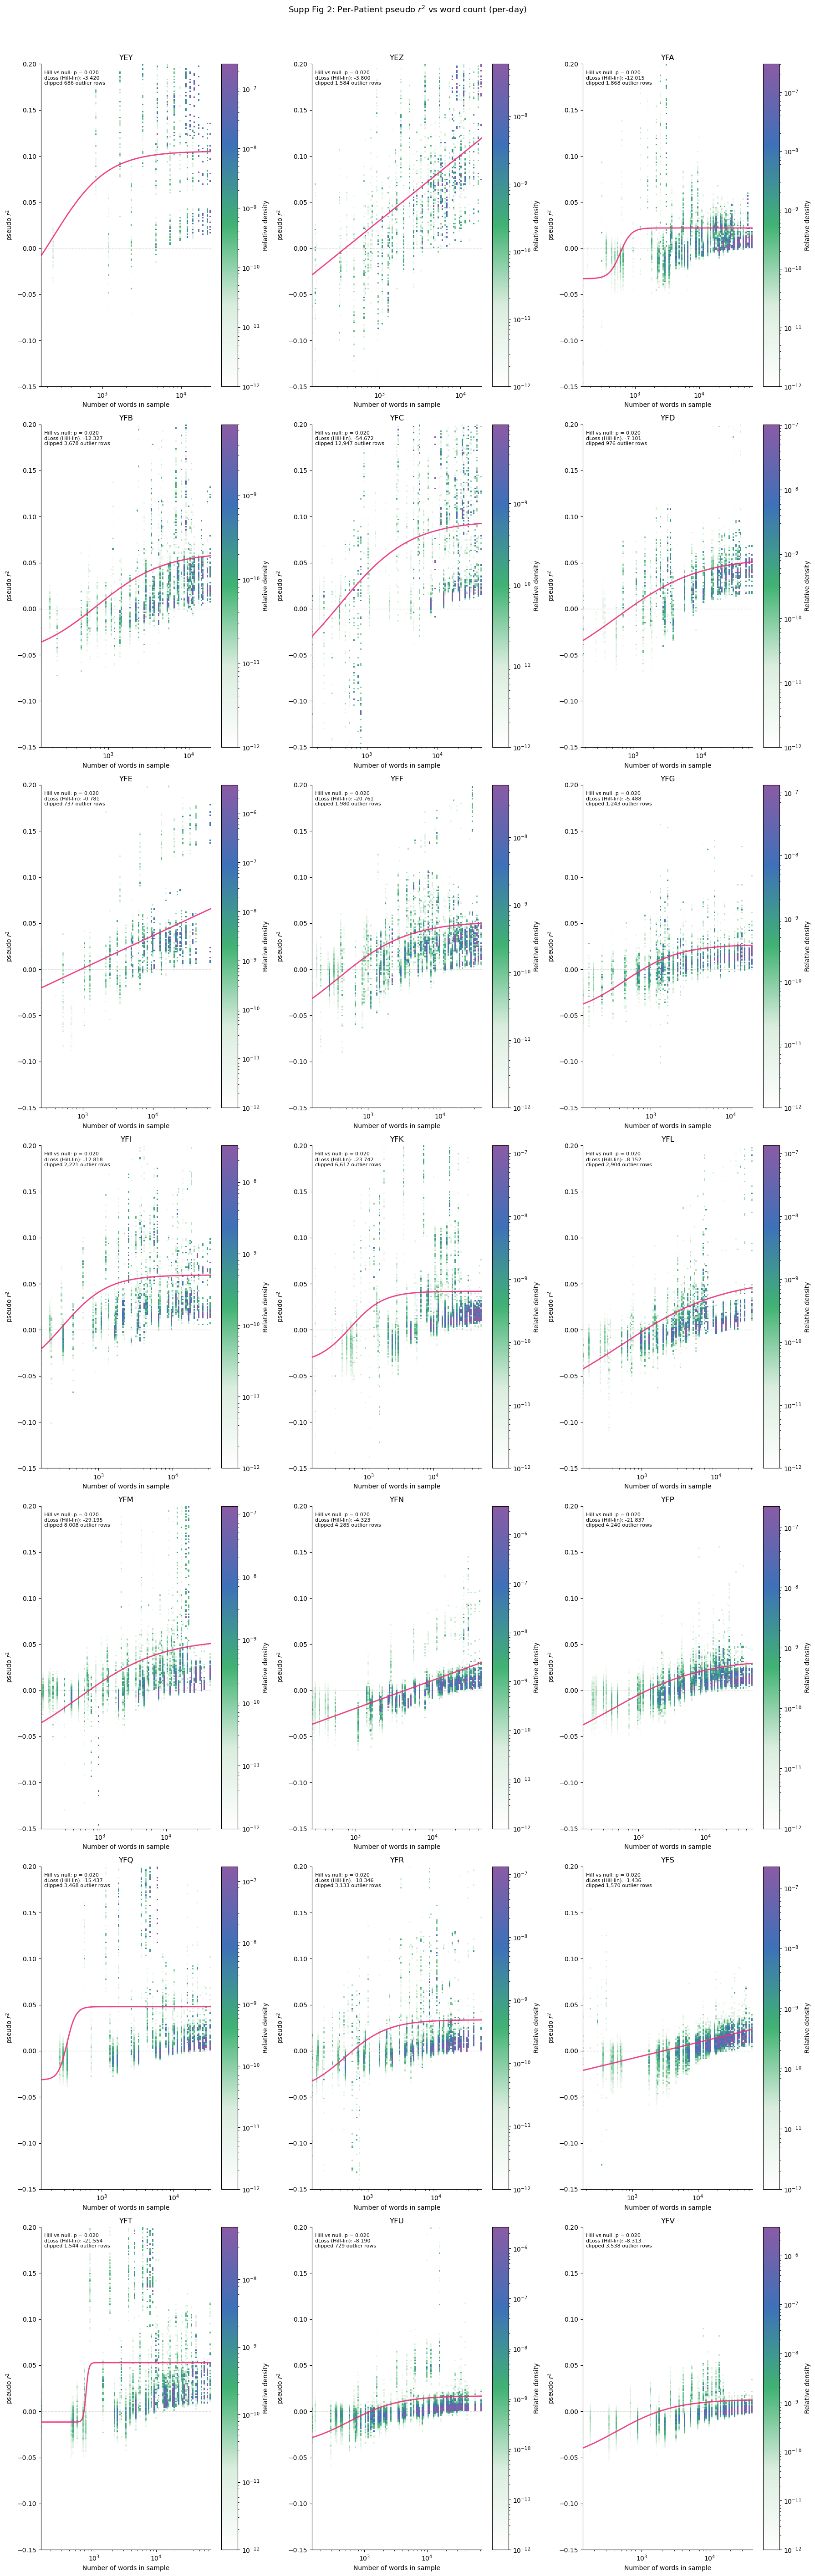

In [26]:
if not pts_perd:
    print('No per-day data available for Supp Figure 2.')
else:
    ncols = 3
    nrows = int(np.ceil(len(pts_perd) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 8))
    axes = np.array(axes).flatten()

    for i, pt in enumerate(pts_perd):
        pt_df = panD_df[panD_df['patient'] == pt]
        plot_2dhist_hill(pt_df, axes[i], title=pt, n_perm=50)

    for j in range(len(pts_perd), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Supp Fig 2: Per-Patient pseudo $r^2$ vs word count (per-day)',
                 y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'supp2_per_patient_2dhist_perd.svg', format='svg')
    plt.show()

## Combined Figure 5 (A–C)

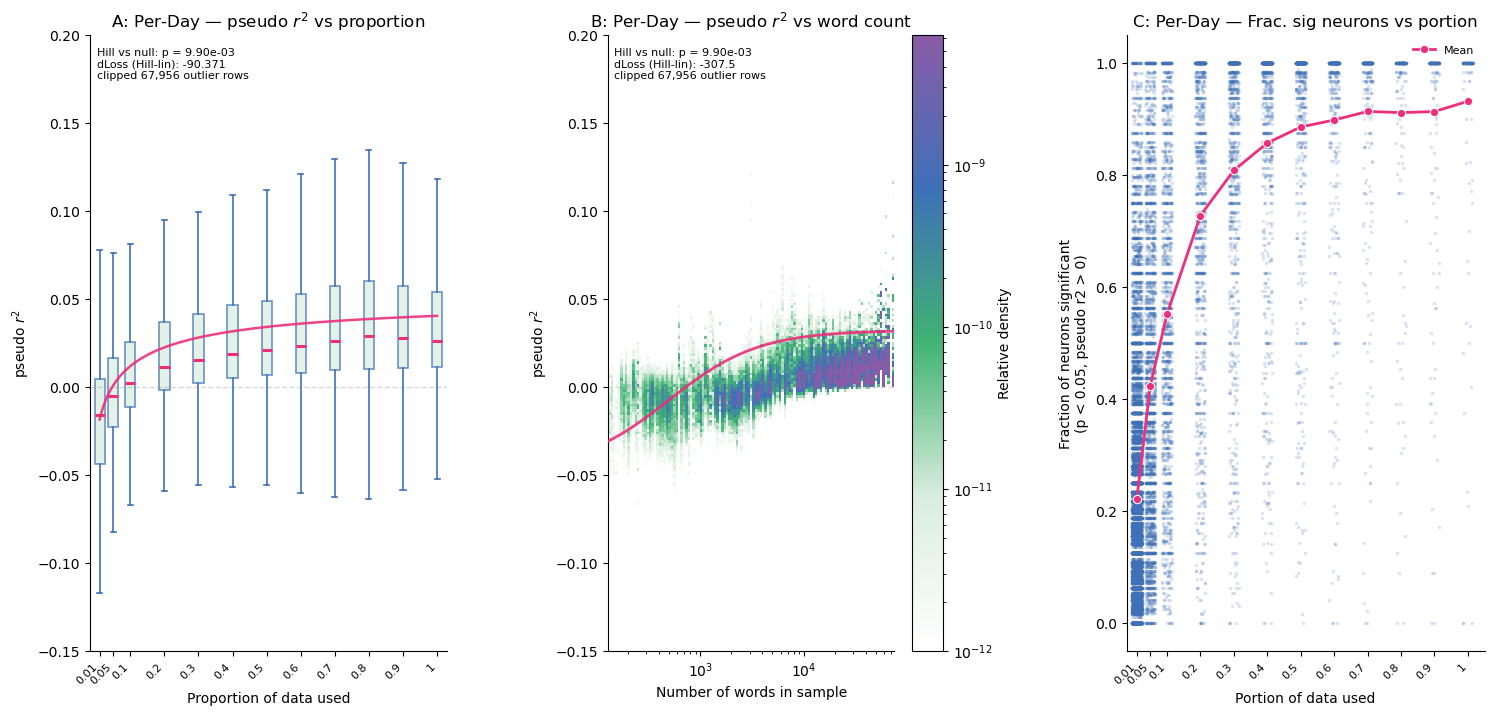

Saved to /mnt/labworlds/Hayden/Hayden_Lab/speech_247/figures_new/figure_5


In [27]:
fig = plt.figure(figsize=(18, 8))
gs  = gridspec.GridSpec(1, 3, figure=fig, hspace=0.4, wspace=0.45)

ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1])
ax_C = fig.add_subplot(gs[0, 2])

plot_boxplot_hill(panC_df, ax_A, title='A: Per-Day — pseudo $r^2$ vs proportion')
plot_2dhist_hill(panD_df,  ax_B, title='B: Per-Day — pseudo $r^2$ vs word count')
plot_scatter_sig_frac(panF_df, ax_C, title='C: Per-Day — Frac. sig neurons vs portion')

plt.savefig(FIG_DIR / 'figure5_combined.svg', format='svg', bbox_inches='tight')
plt.savefig(FIG_DIR / 'figure5_combined.pdf', format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved to {FIG_DIR}')
